In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


In [3]:
class KilterEncoder(nn.Module):
    def __init__(self, latent_dim = 128):
        super(KilterEncoder, self).__init__()

        self.feature_extractor = nn.Sequential(
            
            nn.Conv2d(in_channels=4, out_channels=32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.3),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.3),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.3),

            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.3),

            nn.Flatten()
        )

        self.flattened_size = 256*10*11

        self.fc = nn.Linear(self.flattened_size, latent_dim)

    def forward(self, x):

        features = self.feature_extractor(x)

        latent_vector = self.fc(features)

        return latent_vector


In [4]:
encoder = KilterEncoder(latent_dim=128)

dummy_route = torch.randn(1, 4, 173, 185)

latent_vector = encoder(dummy_route)

print(f"Shape: {latent_vector.shape}")
print(latent_vector[0][:10].detach().numpy())

Shape: torch.Size([1, 128])
[ 0.01556403 -0.0193908  -0.00017661 -0.00843419 -0.01066124  0.00400574
  0.0028063   0.02698778 -0.00326111 -0.00350359]


In [5]:
class KilterDecoder(nn.Module):
    def __init__(self, latent_dim=128):
        super(KilterDecoder, self).__init__()
        

        self.flattened_size = 256 * 10 * 11
        

        self.fc = nn.Linear(latent_dim, self.flattened_size)
        

        self.decoder_cnn = nn.Sequential(

            nn.Unflatten(1, (256, 10, 11)),

            nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            

            nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            
            nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            
            nn.ConvTranspose2d(in_channels=32, out_channels=4, kernel_size=4, stride=2, padding=1),
            
            
            nn.Sigmoid() 
        )

    def forward(self, x):
       
        x = self.fc(x)
        
       
        x = self.decoder_cnn(x)
        
    
        if x.shape[-2:] != (173, 185):
            x = F.interpolate(x, size=(173, 185), mode='bilinear', align_corners=False)
            
        return x

In [6]:
encoder = KilterEncoder(latent_dim=128)
decoder = KilterDecoder(latent_dim=128)

feature_vector = encoder(dummy_route)

print(f"original route size: {dummy_route.shape}")

print(f"encoded vector size: {feature_vector.shape}")

reconstructed_vector = decoder(feature_vector)

print(f"reconsctructed size: {reconstructed_vector.shape}")

original route size: torch.Size([1, 4, 173, 185])
encoded vector size: torch.Size([1, 128])
reconsctructed size: torch.Size([1, 4, 173, 185])


In [7]:
class KilterAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(KilterAE, self).__init__()

        self.encoder = KilterEncoder(latent_dim=128)
        self.decoder = KilterDecoder(latent_dim=128)

    
    def forward(self, x):

        latent_space = self.encoder(x)

        reconstruction = self.decoder(latent_space)

        return reconstruction, latent_space


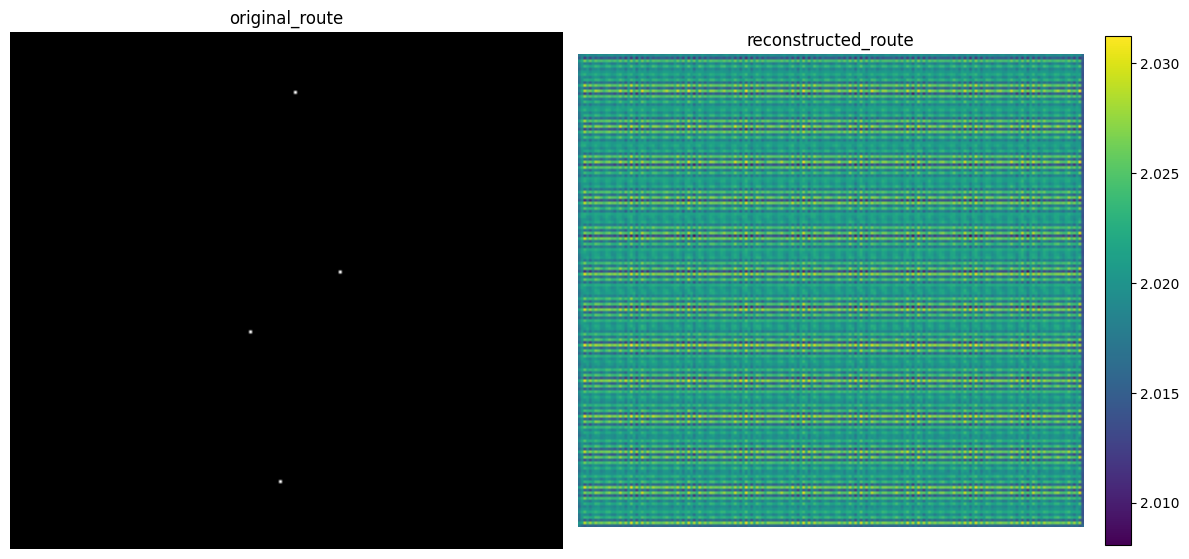

In [8]:
raw_model = KilterAE(latent_dim=128)
raw_model.eval()


test_route = torch.zeros(1, 4, 173, 185)
test_route[0, 0, 150, 90] = 1.0  
test_route[0, 1, 100, 80] = 1.0  
test_route[0, 1, 80, 110] = 1.0  
test_route[0, 2, 20, 95]  = 1.0

with torch.no_grad():
    reconctruction, _ = raw_model(test_route)

img_original = test_route[0].sum(dim=0).numpy()
img_reconstructed = reconctruction[0].sum(dim=0).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12,6))

axes[0].imshow(img_original, cmap='grey')
axes[0].axis("off")
axes[0].set_title("original_route")

im = axes[1].imshow(img_reconstructed, cmap='viridis')
axes[1].axis("off")
axes[1].set_title("reconstructed_route")

fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [9]:
import torch.optim as optim

model = KilterAE(latent_dim=128)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

dummy_route = torch.randint(0, 2, (1, 4, 173, 185)).float()

epochs = 100

for epoch in range(epochs):
    
    model.train()
    optimizer.zero_grad()

    reconstruction, latent_vector = model(dummy_route)

    loss = criterion(reconstruction, dummy_route)

    loss.backward()
    
    optimizer.step()

    print(f"Epoch: {epoch+1}/10 || Loss: {loss.item():.4f}")


Epoch: 1/10 || Loss: 0.6937
Epoch: 2/10 || Loss: 0.6936
Epoch: 3/10 || Loss: 0.6929
Epoch: 4/10 || Loss: 0.6903
Epoch: 5/10 || Loss: 0.6904
Epoch: 6/10 || Loss: 0.6886
Epoch: 7/10 || Loss: 0.6791
Epoch: 8/10 || Loss: 0.6595
Epoch: 9/10 || Loss: 0.6504
Epoch: 10/10 || Loss: 0.6331
Epoch: 11/10 || Loss: 0.6236
Epoch: 12/10 || Loss: 0.6051
Epoch: 13/10 || Loss: 0.5960
Epoch: 14/10 || Loss: 0.5817
Epoch: 15/10 || Loss: 0.5666
Epoch: 16/10 || Loss: 0.5570
Epoch: 17/10 || Loss: 0.5478
Epoch: 18/10 || Loss: 0.5375
Epoch: 19/10 || Loss: 0.5288
Epoch: 20/10 || Loss: 0.5188
Epoch: 21/10 || Loss: 0.5090
Epoch: 22/10 || Loss: 0.5017
Epoch: 23/10 || Loss: 0.4945
Epoch: 24/10 || Loss: 0.4862
Epoch: 25/10 || Loss: 0.4863
Epoch: 26/10 || Loss: 0.4813
Epoch: 27/10 || Loss: 0.4754
Epoch: 28/10 || Loss: 0.4653
Epoch: 29/10 || Loss: 0.4614
Epoch: 30/10 || Loss: 0.4538
Epoch: 31/10 || Loss: 0.4498
Epoch: 32/10 || Loss: 0.4439
Epoch: 33/10 || Loss: 0.4406
Epoch: 34/10 || Loss: 0.4399
Epoch: 35/10 || Loss: 0

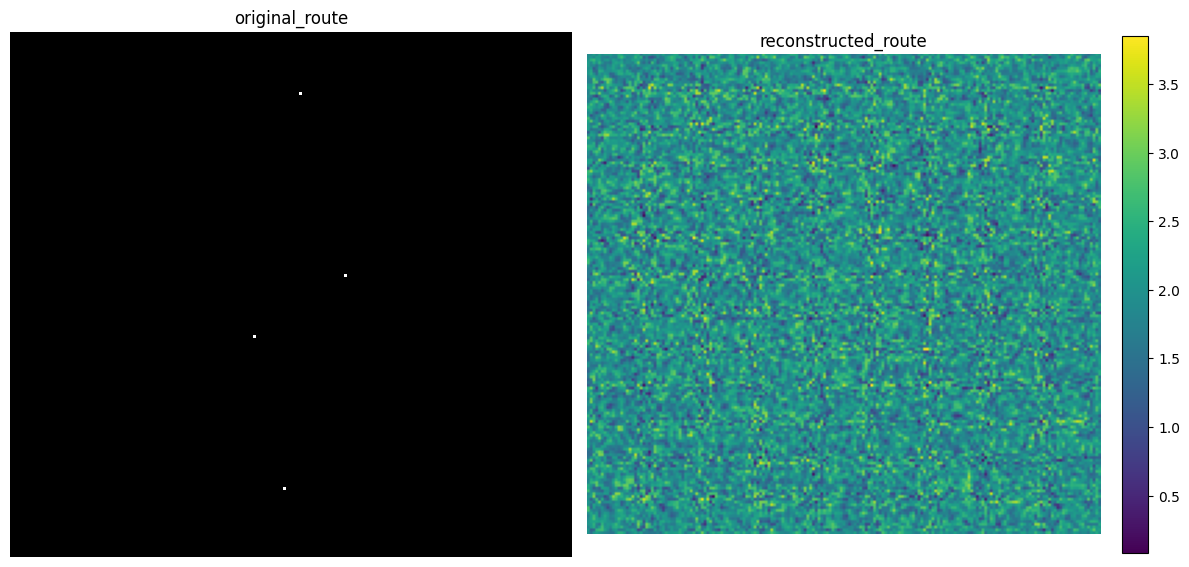

In [10]:
with torch.no_grad():
    reconctruction, _ = model(test_route)

img_original = test_route[0].sum(dim=0).numpy()
img_reconstructed = reconctruction[0].sum(dim=0).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12,6))

axes[0].imshow(img_original, cmap='grey')
axes[0].axis("off")
axes[0].set_title("original_route")

im = axes[1].imshow(img_reconstructed, cmap='viridis')
axes[1].axis("off")
axes[1].set_title("reconstructed_route")

fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()